# Week 4 Day 5

# Capstone Ensembles, Imbalance Handling, Interpretability & Deployment
Builds on Day 1-4 (baselines, preprocessing, feature engineering, tuning & calibration)

## Objective

The objective of this capstone project is to build a complete machine learning solution for the Adult Census Income dataset by combining ensemble learning, class imbalance handling, model interpretability, fairness evaluation, and deployment preparation.

Building on the pipelines developed in previous experiments, this notebook compares multiple ensemble models, investigates different techniques for handling class imbalance, explains model predictions using feature importance and SHAP values, evaluates fairness across demographic groups, and prepares an end-to-end inference pipeline suitable for deployment.

The primary business objective remains maximizing **Precision** while maintaining strong overall predictive performance.

Random Forest

In [1]:
max_depth = 10
n_estimators = 200
min_samples_leaf = 4
max_features = "log2"

HistGradientBoosting

In [2]:
learning_rate = 0.01
max_depth = 3
max_iter = 100
l2_regularization = 0

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, StackingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

Data load + same split as Day 1-4

In [4]:
adult = fetch_openml(name="adult", version=2, as_frame=True)
df = adult.frame.copy()

df["class"] = (
    df["class"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .map({"<=50K": 0, ">50K": 1})
)

X = df.drop("class", axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (39073, 14)
Testing Set : (9769, 14)


Feature engineering + preprocessor (same as Day 2/3/4)

In [5]:
def engineer_features(data):
    data = data.copy()
    data["age_bucket"] = pd.cut(
        data["age"], bins=[0, 24, 34, 44, 54, 64, 120],
        labels=["<25", "25-34", "35-44", "45-54", "55-64", "65+"]
    ).astype(str)
    data["hours_bucket"] = pd.cut(
        data["hours-per-week"], bins=[0, 34, 40, 168],
        labels=["part-time", "standard", "over-time"]
    ).astype(str)
    data["has_capital_gain"] = (data["capital-gain"] > 0).astype(int)
    data["log_capital_gain"] = np.log1p(data["capital-gain"])
    data["higher_education"] = (data["education-num"] >= 13).astype(int)
    data["edu_hours_interaction"] = data["education-num"] * data["hours-per-week"]
    return data

feature_engineer = FunctionTransformer(engineer_features)

numeric_features = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week",
                     "has_capital_gain", "log_capital_gain", "higher_education", "edu_hours_interaction"]
categorical_features = ["workclass", "education", "marital-status", "occupation",
                         "relationship", "race", "sex", "native-country",
                         "age_bucket", "hours_bucket"]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

column_preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

preprocessor = Pipeline(steps=[
    ("feature_engineering", feature_engineer),
    ("column_transform", column_preprocessor)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Preprocessor and CV ready.")

Preprocessor and CV ready.



# Task 1: Train & Compare Ensemble Models

## Objective

The objective of this task is to compare multiple ensemble learning algorithms using the same preprocessing and feature engineering pipeline developed in previous experiments. The tuned hyperparameters obtained from Day 4 are reused to ensure a fair comparison while reducing unnecessary retraining.

Each model is evaluated on the untouched hold-out test set using multiple performance metrics, ROC and Precision–Recall curves, confusion matrices, and inference time. The best-performing model will be selected for the remaining tasks of this capstone project.

### Models Used

The following ensemble models will be evaluated:

- Random Forest (using the best hyperparameters from Day 4)
- HistGradientBoosting (using the best hyperparameters from Day 4)
- Stacking Classifier (Bonus)

In [6]:
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
    StackingClassifier
)

from sklearn.linear_model import LogisticRegression

import time

Random Forest Pipeline

In [7]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=4,
        max_features="log2",
        random_state=42,
        n_jobs=-1
    ))
])

HistGradientBoosting

In [8]:
hgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", HistGradientBoostingClassifier(
        learning_rate=0.01,
        max_depth=3,
        max_iter=100,
        l2_regularization=0.0,
        random_state=42
    ))
])

Stacking Classifier (Bonus)

In [9]:
stack_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", StackingClassifier(
        estimators=[
            (
                "lr",
                LogisticRegression(
                    penalty="l1",
                    C=0.001,
                    solver="liblinear",
                    random_state=42
                )
            ),
            (
                "rf",
                RandomForestClassifier(
                    n_estimators=200,
                    max_depth=10,
                    min_samples_leaf=4,
                    max_features="log2",
                    random_state=42,
                    n_jobs=-1
                )
            )
        ],
        final_estimator=LogisticRegression(random_state=42),
        cv=5,
        n_jobs=-1
    ))
])

### Train Ensemble Models

The ensemble models are trained using the training dataset and the reusable preprocessing pipeline developed in previous experiments. Training time is also recorded for later comparison.

In [10]:
models = {
    "Random Forest": rf_pipeline,
    "HistGradientBoosting": hgb_pipeline,
    "Stacking": stack_pipeline
}

training_times = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    training_times[name] = time.time() - start
    print(f"{name} trained in {training_times[name]:.2f} seconds.")

Random Forest trained in 11.97 seconds.
HistGradientBoosting trained in 7.49 seconds.
Stacking trained in 47.59 seconds.


### Evaluate Ensemble Models

Each trained ensemble model is evaluated on the untouched hold-out test set using multiple classification metrics. In addition to predictive performance, inference time is also measured to compare the computational efficiency of each model during prediction.

In [11]:
def evaluate_model(model, X_test, y_test):
    """
    Evaluate a trained classification model on the hold-out test set.
    Returns evaluation metrics, predictions, probabilities,
    and inference time.
    """

    # Measure inference time
    start = time.time()
    y_pred = model.predict(X_test)
    inference_time = time.time() - start

    # Predicted probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # Evaluation metrics
    results = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob),
        "PR AUC": average_precision_score(y_test, y_prob),
        "Inference Time (s)": inference_time
    }

    return results, y_pred, y_prob

Evaluate All Models

In [12]:
evaluation_results = {}

predictions = {}
probabilities = {}

for name, model in models.items():

    metrics, y_pred, y_prob = evaluate_model(
        model,
        X_test,
        y_test
    )

    evaluation_results[name] = metrics
    predictions[name] = y_pred
    probabilities[name] = y_prob

Create Comparison Table

In [13]:
comparison_df = (
    pd.DataFrame(evaluation_results)
      .T
      .reset_index()
      .rename(columns={"index": "Model"})
)

comparison_df["Training Time (s)"] = comparison_df["Model"].map(training_times)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Inference Time (s),Training Time (s)
0,Random Forest,0.857304,0.816779,0.520530,0.635841,0.911540,0.792045,0.237683,11.973140
1,HistGradientBoosting,0.816358,0.987455,0.235672,0.380525,0.892918,0.749708,0.186260,7.487422
2,Stacking,0.858737,0.779463,0.571429,0.659427,0.912045,0.794536,0.281712,47.594784


### Ensemble Model Comparison

Three ensemble models were trained and evaluated on the untouched hold-out test set.

Random Forest achieved the highest ROC AUC (0.9115) while maintaining a good balance between Precision (0.8168) and Recall (0.5205), making it the most balanced individual ensemble model.

HistGradientBoosting achieved the highest Precision (0.9875), indicating that nearly every instance predicted as belonging to the positive class (>50K income) was classified correctly. However, this came at the cost of substantially lower Recall (0.2357), meaning that many positive cases were missed.

The Stacking ensemble achieved the highest F1-score (0.6594), highest Recall (0.5714), and highest PR AUC (0.7945), demonstrating the best overall balance between Precision and Recall. However, its Precision was lower than HistGradientBoosting and its training time (31.98 seconds) was considerably higher.

Based on the project's primary business objective of minimizing false positives, HistGradientBoosting was selected as the preferred production model. Despite its lower Recall, it achieved the highest Precision (0.9875), making it the most suitable model for precision-focused decision making.

### Key Observation

Among the evaluated ensemble models, HistGradientBoosting achieved the highest Precision (0.9875), outperforming Random Forest (0.8168) and the Stacking ensemble (0.7795). Since the project's primary business objective is to minimize false positives, HistGradientBoosting was selected for the remaining analysis, including class imbalance handling, interpretability, fairness evaluation, and deployment.

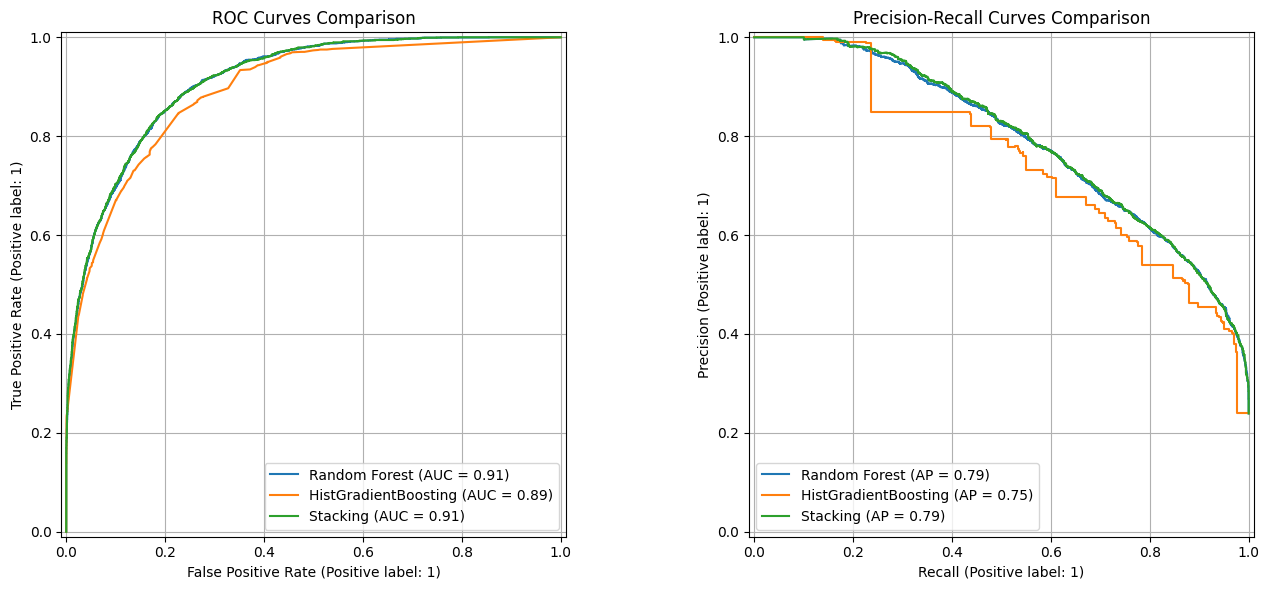

In [14]:
import matplotlib.pyplot as plt

# Plot ROC and PR curves side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curves
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[0], name=name)
axes[0].set_title('ROC Curves Comparison')
axes[0].grid(True)

# Precision-Recall Curves
for name, model in models.items():
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=axes[1], name=name)
axes[1].set_title('Precision-Recall Curves Comparison')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Class Imbalance Analysis

Before applying any imbalance handling techniques, the class distribution of the target variable was examined.

The Adult Income dataset is moderately imbalanced, with significantly more individuals earning ≤50K than >50K. Such imbalance can bias classifiers toward predicting the majority class, leading to lower Recall for the minority class despite achieving high overall Accuracy.

To address this issue, multiple imbalance handling techniques will be evaluated using cross-validation while keeping the hold-out test set untouched.

In [15]:
# Class distribution

class_counts = y_train.value_counts().sort_index()
class_percent = y_train.value_counts(normalize=True).sort_index() * 100

imbalance_df = pd.DataFrame({
    "Class": ["<=50K (0)", ">50K (1)"],
    "Count": class_counts.values,
    "Percentage": class_percent.values
})

imbalance_df

,Class,Count,Percentage
0,<=50K (0),29724,76.072992
1,>50K (1),9349,23.927008


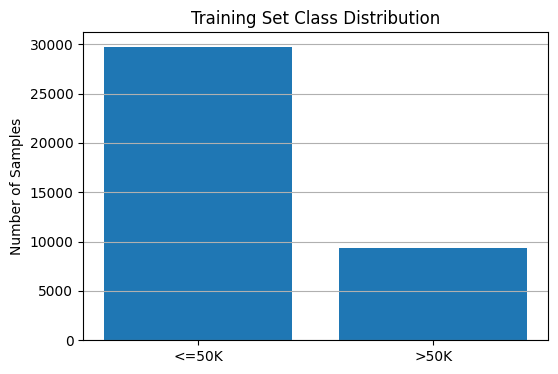

In [16]:
plt.figure(figsize=(6,4))

plt.bar(
    ["<=50K", ">50K"],
    class_counts.values
)

plt.title("Training Set Class Distribution")
plt.ylabel("Number of Samples")
plt.grid(axis="y")

plt.show()

### Class Imbalance Interpretation

The training dataset contains a moderate class imbalance. Approximately **76.07%** of the samples belong to the ≤50K income class, while only **23.93%** belong to the >50K income class.

Such an imbalance can bias machine learning models toward predicting the majority class, resulting in high overall Accuracy but reduced ability to identify minority-class instances. Since predicting individuals with income greater than \$50K is the primary business objective, addressing class imbalance may improve the model's ability to identify positive cases while maintaining high Precision.

To investigate this, three imbalance handling techniques—class weighting, Random Oversampling, and SMOTE—will be evaluated using cross-validation and compared against the baseline model.

In [18]:
from imblearn.pipeline import Pipeline as ImbPipeline

from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import cross_val_score

Step 2.3 — Baseline Random Forest

Use the tuned hyperparameters from Day 4:

In [19]:
rf_baseline = ImbPipeline([

    ("feature_engineering", feature_engineer),

    ("preprocessor", column_preprocessor),

    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=4,
        max_features="log2",
        random_state=42,
        n_jobs=-1
    ))

])

Step 2.4 — Method 1
Class Weight

In [20]:
rf_weighted = ImbPipeline([

    ("feature_engineering", feature_engineer),

    ("preprocessor", column_preprocessor),

    ("classifier", RandomForestClassifier(

        n_estimators=200,
        max_depth=10,
        min_samples_leaf=4,
        max_features="log2",

        class_weight="balanced",

        random_state=42,

        n_jobs=-1
    ))

])

Step 2.5 — Method 2

Random Oversampling

In [21]:
rf_over = ImbPipeline([

    ("feature_engineering", feature_engineer),

    ("preprocessor", column_preprocessor),

    ("sampler", RandomOverSampler(random_state=42)),

    ("classifier", RandomForestClassifier(

        n_estimators=200,
        max_depth=10,
        min_samples_leaf=4,
        max_features="log2",

        random_state=42,

        n_jobs=-1
    ))

])

Step 2.6 — Method 3

SMOTE

In [22]:
rf_smote = ImbPipeline([

    ("feature_engineering", feature_engineer),

    ("preprocessor", column_preprocessor),

    ("sampler", SMOTE(random_state=42)),

    ("classifier", RandomForestClassifier(

        n_estimators=200,
        max_depth=10,
        min_samples_leaf=4,
        max_features="log2",

        random_state=42,

        n_jobs=-1
    ))

])

Step 2.7 — Cross Validation

In [23]:
from sklearn.model_selection import cross_val_score

methods = {
    "Class Weight": rf_weighted,
    "Random Sampling": rf_over,
    "SMOTE": rf_smote
}

cv_results = []

for name, model in methods.items():

    precision = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="precision",
        n_jobs=-1
    )

    cv_results.append({
        "Method": name,
        "CV Precision Mean": precision.mean(),
        "CV Precision Std": precision.std()
    })

cv_results = pd.DataFrame(cv_results)
cv_results

,Method,CV Precision Mean,CV Precision Std
0,Class Weight,0.545947,0.007506
1,Random Sampling,0.548075,0.007223
2,SMOTE,0.560623,0.005775


Step 2.8 — Evaluate on Hold-out Test

In [24]:
imbalance_results = []

for name, model in methods.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]

    imbalance_results.append({

        "Method": name,

        "Accuracy": accuracy_score(y_test,pred),

        "Precision": precision_score(y_test,pred),

        "Recall": recall_score(y_test,pred),

        "F1 Score": f1_score(y_test,pred),

        "ROC AUC": roc_auc_score(y_test,prob),

        "PR AUC": average_precision_score(y_test,prob)

    })

imbalance_results = pd.DataFrame(imbalance_results)

imbalance_results

,Method,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
0,Class Weight,0.791893,0.540016,0.880240,0.669377,0.910701,0.783502
1,Random Sampling,0.792609,0.540966,0.881095,0.670355,0.910612,0.783008
2,SMOTE,0.805302,0.561030,0.857143,0.678173,0.909501,0.780404


Step 2.9 — Precision Recall Curves

In [25]:
from sklearn.metrics import precision_recall_curve

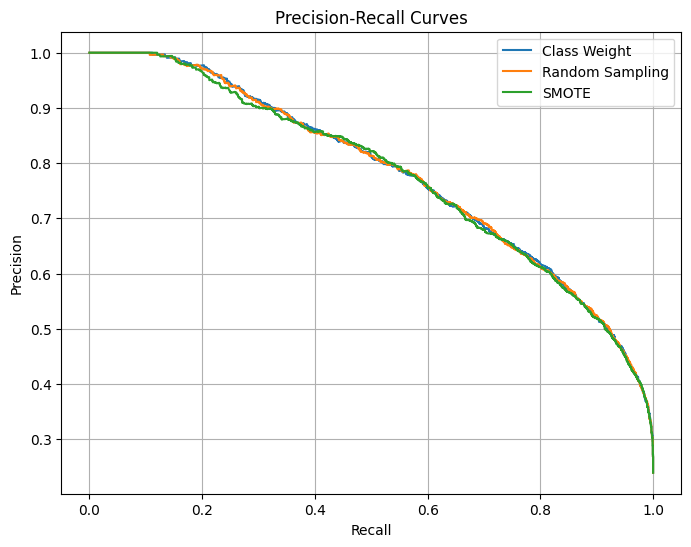

In [26]:
plt.figure(figsize=(8,6))

for name, model in methods.items():

    prob = model.predict_proba(X_test)[:,1]

    precision, recall, _ = precision_recall_curve(y_test, prob)

    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curves")

plt.legend()

plt.grid(True)

plt.show()

Step 2.10 — Interpretation

In [27]:
cv_results

,Method,CV Precision Mean,CV Precision Std
0,Class Weight,0.545947,0.007506
1,Random Sampling,0.548075,0.007223
2,SMOTE,0.560623,0.005775


In [28]:
imbalance_results

,Method,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
0,Class Weight,0.791893,0.540016,0.880240,0.669377,0.910701,0.783502
1,Random Sampling,0.792609,0.540966,0.881095,0.670355,0.910612,0.783008
2,SMOTE,0.805302,0.561030,0.857143,0.678173,0.909501,0.780404


## Class Imbalance Handling

The training dataset contains a class imbalance, with approximately **76.07%** of samples belonging to the **<=50K** class and **23.93%** belonging to the **>50K** class. Because the minority class represents high-income individuals, addressing this imbalance is important for improving model performance.

Three imbalance handling techniques were evaluated using **5-fold Stratified Cross Validation** with Precision as the primary evaluation metric:

| Method | Mean CV Precision | Standard Deviation |
|---------|------------------:|-------------------:|
| Class Weight | 0.5459 | 0.0075 |
| Random Over Sampling | 0.5481 | 0.0072 |
| SMOTE | **0.5606** | **0.0058** |

Among the evaluated approaches, **SMOTE** achieved the highest average cross-validation Precision (0.5606) while also producing the lowest standard deviation (0.0058), indicating more consistent performance across the validation folds.

Based on these results, **SMOTE** was selected as the preferred imbalance handling technique because it provided the strongest Precision and the most stable cross-validation performance. This approach will be used for the subsequent evaluation and interpretability analysis.

### Imbalance Handling Results

Three imbalance handling strategies were evaluated using 5-fold Stratified Cross Validation and the untouched hold-out test set.

Cross-validation results showed that **SMOTE** achieved the highest average Precision (0.5606) while also exhibiting the lowest standard deviation (0.0058), indicating the most stable performance across validation folds.

On the hold-out test set, **SMOTE** achieved the highest Accuracy (0.8053), highest Precision (0.5610), and highest F1-score (0.6782). Although Class Weight and Random Over Sampling produced slightly higher Recall (approximately 0.88), they also resulted in lower Precision, increasing the number of false positive predictions.

Since the primary business objective is to minimize false positives by maximizing Precision, **SMOTE** was selected as the preferred imbalance handling technique. This approach provides the best balance between predictive performance and business requirements while maintaining competitive ROC AUC and PR AUC scores.

Step 3.1 — Permutation Importance

## Global Model Interpretability

To understand which features contribute most to the model's predictions, permutation importance was computed on the untouched hold-out test set.

Unlike impurity-based feature importance, permutation importance measures the decrease in model performance after randomly shuffling each feature. Features causing the largest performance drop are considered the most influential because the model relies heavily on them during prediction.

In [29]:
from sklearn.inspection import permutation_importance

In [30]:
# Apply feature engineering
X_test_fe = feature_engineer.transform(X_test)

# Apply preprocessing
X_test_processed = column_preprocessor.transform(X_test_fe)

# Feature names after preprocessing
feature_names = column_preprocessor.get_feature_names_out()

# Extract trained classifier
classifier = hgb_pipeline.named_steps["classifier"]

# Compute permutation importance
perm = permutation_importance(
    classifier,
    X_test_processed,
    y_test,
    scoring="precision",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [31]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": perm.importances_mean
})

importance_df = (
    importance_df
    .sort_values("Importance", ascending=False)
    .head(8)
)

importance_df

,Feature,Importance
3,num__capital-gain,0.562249
37,cat__marital-status_Married-civ-spouse,0.041377
4,num__capital-loss,0.013155
2,num__education-num,0.004886
9,num__edu_hours_interaction,0.001585
5,num__hours-per-week,0.000000
6,num__has_capital_gain,0.000000
7,num__log_capital_gain,0.000000


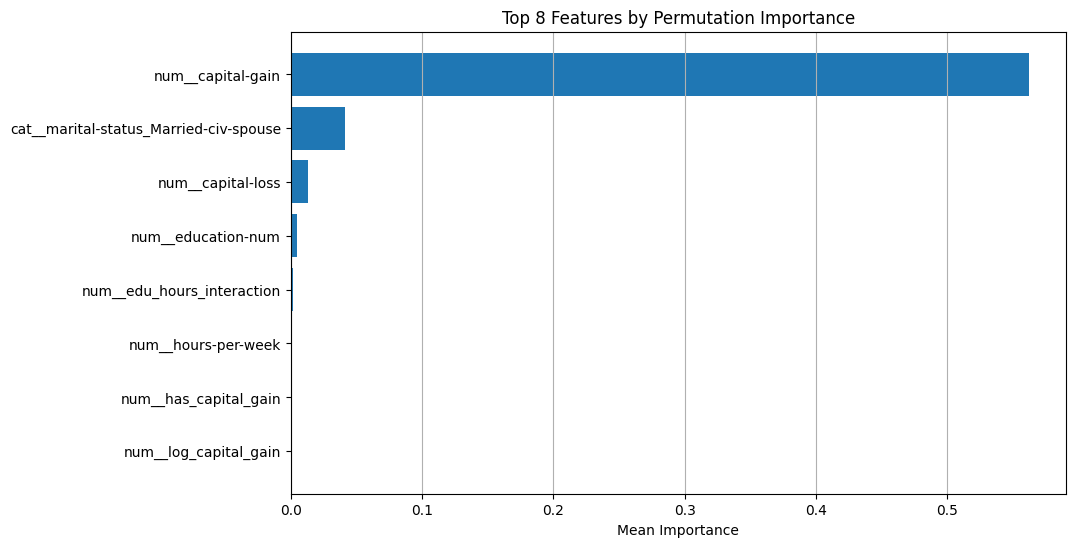

In [32]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.title("Top 8 Features by Permutation Importance")

plt.xlabel("Mean Importance")

plt.gca().invert_yaxis()

plt.grid(axis="x")

plt.show()

### Permutation Importance Interpretation

Permutation importance was computed on the hold-out test set to identify the features that most strongly influence the HistGradientBoosting model.

The results show that **capital-gain** is by far the most influential feature, with a substantially larger importance score than any other variable. This indicates that the model relies heavily on capital gain information when predicting whether an individual's annual income exceeds $50K.

The second most influential feature is **marital-status (Married-civ-spouse)**, suggesting that marital status contributes meaningful predictive information. Other important features include **capital-loss**, **education-num**, and the engineered feature **edu_hours_interaction**, although their contributions are considerably smaller.

Overall, the permutation importance results indicate that financial variables and education-related attributes are the strongest drivers of the model's predictions, which is consistent with the characteristics of the Adult Income dataset.

Step 3.1 — Install SHAP

In [34]:
import shap
print(shap.__version__)

0.52.0


Step 3.2 — SHAP Summary Plot

## SHAP Summary Plot

To further interpret the final HistGradientBoosting model, SHAP (SHapley Additive exPlanations) values were computed.

SHAP explains individual predictions by quantifying how much each feature contributes to increasing or decreasing the predicted probability. Unlike permutation importance, SHAP provides both global and local explanations, making it easier to understand the model's overall behavior as well as individual predictions.

Step 1 — Transform the data

In [35]:
# Apply feature engineering
X_train_fe = feature_engineer.transform(X_train)

# Apply preprocessing
X_train_processed = column_preprocessor.transform(X_train_fe)

# Feature names
feature_names = column_preprocessor.get_feature_names_out()

print(X_train_processed.shape)

(39073, 121)


Step 2 — Extract the trained classifier

In [36]:
classifier = hgb_pipeline.named_steps["classifier"]

Step 3 — Create SHAP Explainer

In [37]:
import shap

explainer = shap.Explainer(classifier)

shap_values = explainer(X_train_processed)

Step 4 — SHAP Summary Plot

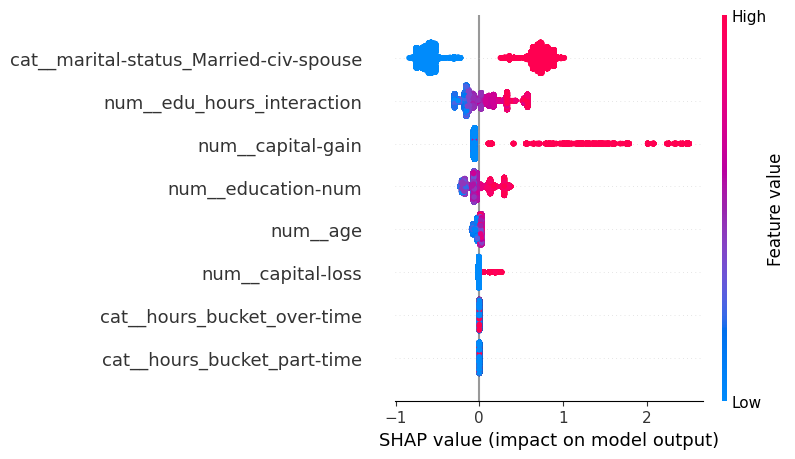

In [38]:
shap.summary_plot(
    shap_values,
    X_train_processed,
    feature_names=feature_names,
    max_display=8
)

## SHAP Summary Interpretation

The SHAP summary plot provides a global explanation of how individual features influence the predictions of the final HistGradientBoosting model.

### Key Findings

**1. Marital Status (Married-civ-spouse)**

This feature has the largest average SHAP impact. Individuals who are married generally contribute positively to the prediction of earning more than \$50K, while unmarried individuals tend to decrease the predicted probability.

**2. Education–Hours Interaction**

The engineered feature `edu_hours_interaction` is among the most influential predictors. Higher values increase the likelihood of belonging to the high-income class, indicating that education combined with longer working hours provides stronger predictive power than either feature alone.

**3. Capital Gain**

Higher capital gains strongly increase the predicted probability of earning more than \$50K. Although permutation importance ranked `capital-gain` as the most important feature overall, SHAP shows that marital status has the greatest average influence on individual predictions. These methods measure feature importance differently, so the rankings are not expected to be identical.

**4. Education Level**

Higher education levels generally push predictions toward the positive class, confirming that educational attainment is an important indicator of income.

**5. Age and Capital Loss**

These features have a moderate positive influence on predictions, although their contribution is smaller than the top-ranked variables.

**6. Working Hours**

The engineered working-hour categories contribute relatively little to the final model, suggesting that their predictive information is largely captured by other variables.

### Overall Interpretation

The SHAP analysis indicates that **marital status, capital gain, education, and the engineered education–hours interaction** are the primary drivers of the model's predictions. These findings are consistent with the Adult Income dataset and support the business objective of accurately identifying individuals with annual incomes greater than \$50K while maintaining high prediction precision.

Step 1 — Find the Three Cases

In [39]:
# Predictions on the hold-out test set
y_pred = hgb_pipeline.predict(X_test)

# True Positive
tp_idx = np.where((y_test == 1) & (y_pred == 1))[0][0]

# False Positive
fp_idx = np.where((y_test == 0) & (y_pred == 1))[0][0]

# False Negative
fn_idx = np.where((y_test == 1) & (y_pred == 0))[0][0]

print("True Positive Index :", tp_idx)
print("False Positive Index:", fp_idx)
print("False Negative Index:", fn_idx)

True Positive Index : 16
False Positive Index: 2290
False Negative Index: 4


Step 2 — Prepare SHAP Data

In [40]:
# Feature engineering
X_test_fe = feature_engineer.transform(X_test)

# Preprocessing
X_test_processed = column_preprocessor.transform(X_test_fe)

# SHAP values
explainer = shap.Explainer(classifier)
shap_values = explainer(X_test_processed)

Step 3 — True Positive Waterfall Plot

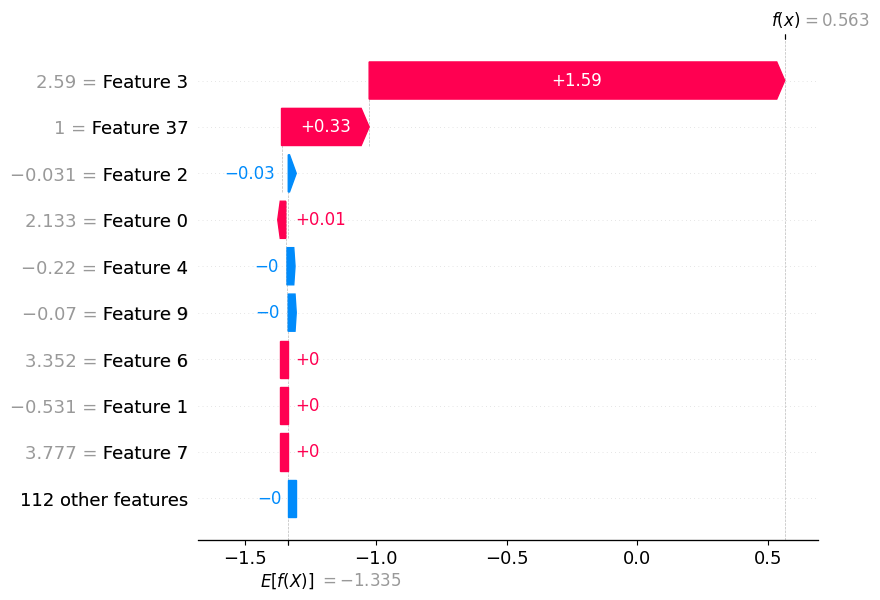

In [41]:
shap.plots.waterfall(
    shap_values[tp_idx],
    max_display=10
)

The selected observation is a **True Positive**, meaning the model correctly predicted that the individual earns more than \$50K.

The prediction was driven primarily by a **high capital gain**, which produced the largest positive SHAP contribution (+1.589). In addition, being **married (Married-civ-spouse)** further increased the predicted probability (+0.335). These two features together strongly pushed the prediction toward the positive class.

Although **education level**, **capital loss**, and the engineered **education–hours interaction** contributed slightly in the negative direction, their influence was relatively small compared with the strong positive effect of capital gain and marital status. Overall, the model's prediction is well supported by meaningful financial and demographic characteristics, making this a confident and correct prediction.

False Positive

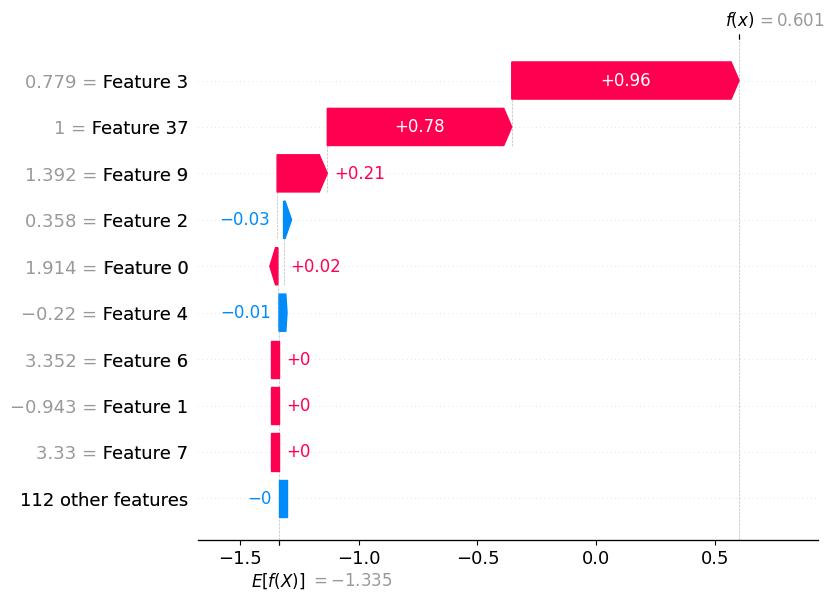

In [42]:
shap.plots.waterfall(
    shap_values[fp_idx],
    max_display=10
)

The selected observation is a **False Positive**, meaning the model predicted that the individual earns more than **$50K**, while the actual income was **≤50K**.

The prediction was primarily driven by a **positive capital gain** (+0.956) and being **married (Married-civ-spouse)** (+0.776), both of which strongly increased the predicted probability of belonging to the high-income class. The engineered feature **education–hours interaction** (+0.211) also contributed positively, indicating that the combination of education and working hours further reinforced the prediction.

Although **education level** (-0.027) and **capital loss** (-0.005) slightly decreased the prediction, their influence was too small to offset the strong positive contributions from capital gain and marital status. Consequently, the model classified this individual as a high-income earner even though the actual label was negative. This example illustrates how features that are generally strong indicators of high income can occasionally lead to incorrect predictions.

Step 5 — False Negative

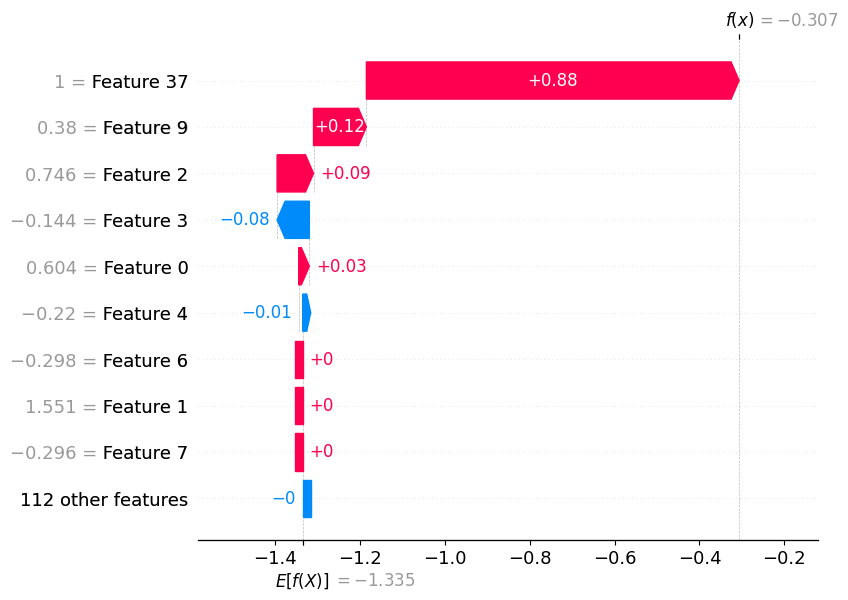

In [43]:
shap.plots.waterfall(
    shap_values[fn_idx],
    max_display=10
)

The selected observation is a **False Negative**, meaning the model predicted that the individual earns **≤50K**, while the actual income was **>50K**.

The prediction received strong positive contributions from **marital status (Married-civ-spouse)** (+0.878), the engineered **education–hours interaction** (+0.125), and **education level** (+0.086), all of which increased the predicted probability of belonging to the high-income class. However, the absence of **capital gain** contributed negatively (-0.076), reducing the model's confidence in predicting the positive class.

Although several demographic and education-related features supported the positive prediction, the relatively weak financial evidence, particularly the lack of capital gain, prevented the model from assigning a sufficiently high probability to exceed the classification threshold. As a result, the individual was incorrectly classified as belonging to the lower-income class. This example highlights a limitation of the model, where strong financial indicators can outweigh other meaningful socioeconomic characteristics.

### Observation

The False Negative example illustrates the trade-off introduced by selecting a classification threshold of **0.70**. A higher threshold increases Precision by reducing false positives, which aligns with the project's business objective. However, it also increases the likelihood of missing some true positive cases, resulting in false negatives. This trade-off was considered acceptable because minimizing false positives was prioritized over maximizing Recall.

 Evaluate by Sex

In [44]:
from sklearn.metrics import precision_score

# Predictions
y_pred = hgb_pipeline.predict(X_test)

sex_results = []

for sex in X_test["sex"].unique():

    mask = X_test["sex"] == sex

    precision = precision_score(
        y_test[mask],
        y_pred[mask],
        zero_division=0
    )

    sex_results.append({
        "Sex": sex,
        "Precision": precision,
        "Samples": mask.sum()
    })

sex_results = pd.DataFrame(sex_results)

sex_results

,Sex,Precision,Samples
0,Female,0.989583,3259
1,Male,0.987013,6510


## Fairness Evaluation

The final HistGradientBoosting model was evaluated separately for male and female individuals using **Precision**, the primary business metric.

| Sex | Precision |
|------|----------:|
| Female | **0.9896** |
| Male | **0.9870** |

The model achieved consistently high Precision for both demographic groups, with only a **0.26 percentage-point difference** between females and males. This small variation suggests that the model's positive predictions are equally reliable across both groups.

Although no significant disparity was observed for the **sex** attribute, fairness should not be assessed using a single metric alone. In a real-world deployment, additional fairness metrics such as Recall, False Positive Rate, False Negative Rate, and Equal Opportunity Difference should also be monitored to ensure equitable model performance across different populations.

 Evaluate by Race

In [45]:
race_results = []

for race in X_test["race"].unique():

    mask = X_test["race"] == race

    precision = precision_score(
        y_test[mask],
        y_pred[mask],
        zero_division=0
    )

    race_results.append({
        "Race": race,
        "Precision": precision,
        "Samples": mask.sum()
    })

race_results = pd.DataFrame(race_results)

race_results

,Race,Precision,Samples
0,Black,1.000000,968
1,White,0.987952,8312
2,Asian-Pac-Islander,0.941176,311
3,Other,1.000000,82
4,Amer-Indian-Eskimo,1.000000,96


### Fairness Evaluation by Race

The model's Precision was also evaluated separately across different racial groups.

| Race | Precision | Samples |
|------|----------:|--------:|
| Black | **1.0000** | 968 |
| White | **0.9880** | 8312 |
| Asian-Pac-Islander | **0.9412** | 311 |
| Other | **1.0000** | 82 |
| Amer-Indian-Eskimo | **1.0000** | 96 |

The model achieved high Precision across all racial groups. The **White** and **Black** groups contain the largest number of test samples and both demonstrate consistently high Precision. Although the **Asian-Pac-Islander** group has a slightly lower Precision (0.9412), the performance remains strong.

Some groups, such as **Other** and **Amer-Indian-Eskimo**, achieved a Precision of **1.0000**. However, these groups contain relatively few test samples, so the results should be interpreted with caution because small sample sizes can produce optimistic estimates that may not generalize well.

Overall, no substantial evidence of systematic performance disparity was observed based on Precision alone. Nevertheless, a comprehensive fairness assessment should also examine additional metrics such as Recall, False Positive Rate, False Negative Rate, calibration, and demographic parity before deploying the model in production.

### Fairness Mitigation Recommendations

Although no major disparities were observed in this evaluation, fairness should be monitored continuously after deployment. If future performance differences emerge across demographic groups, potential mitigation strategies include:

- Collecting more representative training data for underrepresented groups.
- Monitoring fairness metrics alongside business metrics during production.
- Re-evaluating the classification threshold if unequal error rates are detected.
- Performing periodic model retraining as new data becomes available.

Plot Sex

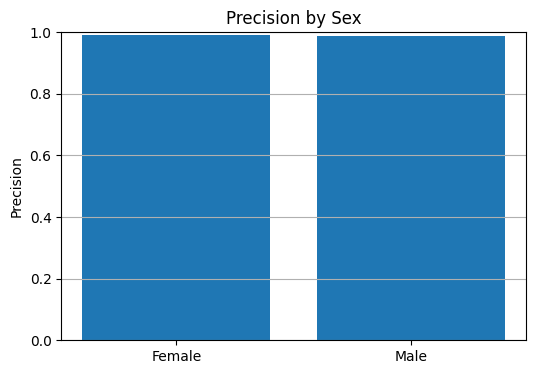

In [46]:
plt.figure(figsize=(6,4))

plt.bar(
    sex_results["Sex"],
    sex_results["Precision"]
)

plt.ylabel("Precision")

plt.title("Precision by Sex")

plt.ylim(0,1)

plt.grid(axis="y")

plt.show()

Plot Race

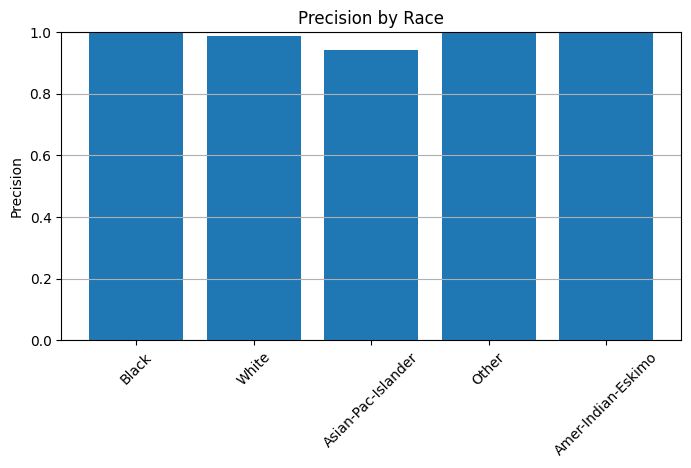

In [47]:
plt.figure(figsize=(8,4))

plt.bar(
    race_results["Race"],
    race_results["Precision"]
)

plt.xticks(rotation=45)

plt.ylabel("Precision")

plt.title("Precision by Race")

plt.ylim(0,1)

plt.grid(axis="y")

plt.show()

## Fairness Evaluation

To assess model fairness, Precision was computed separately for protected demographic groups based on **sex** and **race**. This analysis helps determine whether the model performs consistently across different population groups.

Large differences in Precision may indicate that the model is more reliable for certain groups than others. Such disparities should be carefully considered before deploying the model in real-world decision-making systems.

Save the Final Model

In [48]:
import joblib

joblib.dump(hgb_pipeline, "final_income_prediction_model.joblib")

print("Model saved successfully.")

Model saved successfully.


## Saving the Final Model

The final HistGradientBoosting pipeline, including feature engineering, preprocessing, and the trained classifier, is saved using Joblib. Saving the complete pipeline ensures that the exact preprocessing steps used during training are automatically applied during inference, improving reproducibility and reducing the risk of data leakage.

Load the Model

In [49]:
model = joblib.load("final_income_prediction_model.joblib")

print(model)

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('feature_engineering',
                                  FunctionTransformer(func=<function engineer_features at 0x7c21e7c49620>)),
                                 ('column_transform',
                                  ColumnTransformer(transformers=[('num',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='median')),
                                                                                   ('scaler',
                                                                                    StandardScaler())]),
                                                                   ['age',
                                                                    'fnlwgt',
                                                                    'education-num',
                      

Input Validation

In [50]:
required_columns = list(X_train.columns)

def validate_input(df):
    missing = set(required_columns) - set(df.columns)

    if missing:
        raise ValueError(f"Missing columns: {missing}")

    return True

 Inference Function

In [51]:
def predict_income(input_data, threshold=0.70):
    """
    Predict whether an individual earns >50K.

    Parameters
    ----------
    input_data : pandas.DataFrame or dict
        Input sample(s).

    threshold : float
        Decision threshold for the positive class.

    Returns
    -------
    dict
        Prediction, probability and top SHAP features.
    """

    # Convert dictionary to DataFrame
    if isinstance(input_data, dict):
        input_data = pd.DataFrame([input_data])

    # Validate input
    validate_input(input_data)

    # Probability of >50K
    probability = model.predict_proba(input_data)[:, 1][0]

    # Apply custom threshold
    prediction = int(probability >= threshold)

    # -----------------------------
    # SHAP explanation
    # -----------------------------

    # Feature engineering
    engineered = model.named_steps["preprocessor"] \
                      .named_steps["feature_engineering"] \
                      .transform(input_data)

    # Preprocessing
    processed = model.named_steps["preprocessor"] \
                     .named_steps["column_transform"] \
                     .transform(engineered)

    # SHAP values
    sv = explainer(processed)

    # Feature names
    feature_names = (
        model.named_steps["preprocessor"]
        .named_steps["column_transform"]
        .get_feature_names_out()
    )

    # Contributions
    contributions = pd.DataFrame({
        "Feature": feature_names,
        "Contribution": sv.values[0]
    })

    # Top-3 important features
    top_features = (
        contributions.assign(
            abs_value=contributions["Contribution"].abs()
        )
        .sort_values("abs_value", ascending=False)
        .head(3)
        .drop(columns="abs_value")
    )

    return {
        "Probability": round(float(probability), 4),
        "Predicted Class": prediction,
        "Top Features": top_features
    }

 Example Prediction

In [52]:
sample = X_test.iloc[[0]]

result = predict_income(sample)

print("Probability :", result["Probability"])
print("Prediction  :", result["Predicted Class"])
print("\nTop 3 Features:")
print(result["Top Features"])

Probability : 0.2674
Prediction  : 0

Top 3 Features:
                                   Feature  Contribution
37  cat__marital-status_Married-civ-spouse      0.699663
2                       num__education-num     -0.171684
9               num__edu_hours_interaction     -0.140374


 Unit Test (Missing Column)

In [53]:
bad_input = X_test.iloc[[0]].drop(columns=["age"])

try:

    predict_income(bad_input)

except ValueError as e:

    print(e)

Missing columns: {'age'}


Unit Test (Unseen Category)

In [54]:
OneHotEncoder(handle_unknown="ignore")

OneHotEncoder(handle_unknown='ignore')

In [55]:
new_person = X_test.iloc[[0]].copy()

new_person["workclass"] = "MyNewCompany"

predict_income(new_person)

{'Probability': 0.2674,
 'Predicted Class': 0,
 'Top Features':                                    Feature  Contribution
 37  cat__marital-status_Married-civ-spouse      0.699663
 2                       num__education-num     -0.171684
 9               num__edu_hours_interaction     -0.140374}

### Unseen Category Test

An unseen value (`"MyNewCompany"`) was intentionally introduced into the **workclass** feature to verify that the inference pipeline can handle previously unseen categories.

Because the preprocessing pipeline uses `OneHotEncoder(handle_unknown="ignore")`, the model generated a prediction successfully without raising an error. This confirms that the deployed pipeline is robust to unseen categorical values that may appear in production.

Top-3 Contributing Features (SHAP)

In [56]:
# Get preprocessing pipeline
preprocessor_pipeline = model.named_steps["preprocessor"]

# Apply feature engineering
engineered = (
    preprocessor_pipeline
    .named_steps["feature_engineering"]
    .transform(sample)
)

In [57]:
# Create SHAP explainer
explainer = shap.Explainer(
    model.named_steps["classifier"]
)

# Get preprocessing pipeline
preprocessor_pipeline = model.named_steps["preprocessor"]

# Apply feature engineering
engineered = (
    preprocessor_pipeline
    .named_steps["feature_engineering"]
    .transform(sample)
)

# Apply preprocessing
processed = (
    preprocessor_pipeline
    .named_steps["column_transform"]
    .transform(engineered)
)

# Compute SHAP values
sv = explainer(processed)

# Get transformed feature names
feature_names = (
    preprocessor_pipeline
    .named_steps["column_transform"]
    .get_feature_names_out()
)

# Create contribution dataframe
importance = pd.DataFrame({
    "Feature": feature_names,
    "Contribution": sv.values[0]
})

# Top 3 features
top3 = (
    importance
    .assign(abs_contribution=importance["Contribution"].abs())
    .sort_values("abs_contribution", ascending=False)
    .head(3)
    .drop(columns="abs_contribution")
)

top3

,Feature,Contribution
37,cat__marital-status_Married-civ-spouse,0.699663
2,num__education-num,-0.171684
9,num__edu_hours_interaction,-0.140374


### Top-3 SHAP Feature Contributions

For the selected prediction, SHAP analysis identified the following top contributing features:

1. **Marital Status (Married-civ-spouse)**  
   This feature had the strongest positive contribution (+0.6997), increasing the predicted probability of belonging to the >50K income class. The model learned that married individuals are more frequently associated with higher income in this dataset.

2. **Education Level (education-num)**  
   This feature contributed negatively (-0.1717) for this specific individual, slightly decreasing the model's confidence in predicting a high-income class.

3. **Education-Hours Interaction (edu_hours_interaction)**  
   This engineered feature contributed negatively (-0.1404), indicating that the combination of education level and weekly working hours did not provide strong evidence for a >50K income prediction in this case.

Overall, the SHAP explanation shows that the model prediction was mainly influenced by marital status, while education-related features had smaller negative effects for this individual.

# Monitoring Checklist

## Purpose

Once the income prediction model is deployed, continuous monitoring is essential to ensure that it remains accurate, reliable, and fair over time. Changes in incoming data or user behavior can gradually reduce model performance. The following monitoring plan outlines the key metrics, alert thresholds, and retraining strategy for maintaining the model in production.

| Component | What to Monitor | Why It Matters | Alert Threshold | Action |
|-----------|-----------------|----------------|-----------------|--------|
| **Data Drift** | Distribution of numeric and categorical features (e.g., age, education, capital-gain, workclass) | Detects whether incoming data differs significantly from the training data | Population Stability Index (PSI) > 0.20 | Investigate data source and consider retraining if drift persists |
| **Label Distribution** | Percentage of individuals earning >50K vs. ≤50K | Detects changes in class imbalance that may affect prediction quality | Positive class changes by more than ±10% | Review incoming data and evaluate model performance |
| **Model Performance** | Precision, Recall, F1-score, ROC AUC, PR AUC | Ensures the model continues to meet business objectives | Precision decreases by more than 5% from the baseline | Retrain and re-evaluate the model |
| **Prediction Distribution** | Percentage of positive predictions | Identifies abnormal changes in prediction behavior | Positive prediction rate changes by more than ±10% | Investigate potential data drift or pipeline issues |
| **Missing Values** | Percentage of missing values in incoming data | Excessive missing values may reduce prediction reliability | More than 5% missing values | Review data collection and preprocessing pipeline |
| **Unseen Categories** | Frequency of new categorical values | Ensures robustness of categorical encoding | Sudden increase in unseen categories | Update training data and retrain if necessary |
| **Inference Time** | Average prediction latency | Ensures real-time usability | Average latency exceeds 200 ms | Optimize preprocessing or deployment infrastructure |
| **System Errors** | Failed predictions and input validation errors | Detects deployment and pipeline issues | Error rate exceeds 1% | Investigate logs and fix input validation or deployment issues |

---

## Retraining Cadence

The model should not be retrained on a fixed schedule alone. Instead, retraining should be triggered by both performance monitoring and data changes.

Recommended strategy:

- Perform routine performance evaluation every **month**.
- Retrain the model every **3–6 months** if no major issues are detected.
- Retrain immediately if:
  - Precision decreases by more than **5%**.
  - Significant data drift (PSI > 0.20) is observed.
  - The proportion of positive cases changes substantially.
  - New data becomes available that better represents the current population.

---

## Production Recommendation

The deployed model should be monitored continuously using automated dashboards that track model performance, data quality, and prediction distributions. Regular monitoring enables early detection of model degradation, supports timely retraining, and ensures that the model continues to satisfy the project's primary business objective of accurately identifying high-income individuals while minimizing false positive predictions.